# Упражнения <a id='tasks'></a>

Необходимо изучить библиотеку [tslearn](https://tslearn.readthedocs.io/en/stable/).

1. Взять выбранные для лабы 14 набор(ы) данных. 

3. Попробовать все методы классификации и регрессии, описанные в блоноте 14 aeon:
    Distance-based 
    Свертки (модели семейства Rocket и Hydra)
    Feature-based
    Deep Learning

    Для каждого подхода обучть не менее 3х разных моделей для классификации и регрессии.
    
     
    

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.impute import SimpleImputer
from aeon.datasets import load_classification
from tslearn.neighbors import KNeighborsTimeSeriesClassifier, KNeighborsTimeSeriesRegressor
from tslearn.metrics import dtw, soft_dtw, ctw
from sktime.transformations.panel.rocket import Rocket
from sktime.transformations.panel.catch22 import Catch22

Train: (67, 1, 24), Test: (1029, 1, 24)


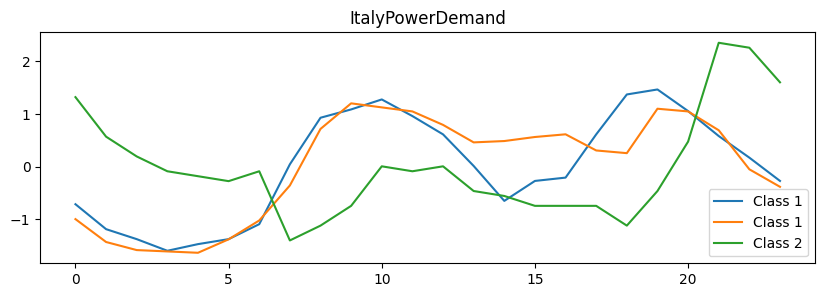

(Text(0.5, 1.0, 'ItalyPowerDemand'),
 None)

In [25]:
# Загрузка данных
X_train, y_train = load_classification("ItalyPowerDemand", split="TRAIN")
X_test, y_test = load_classification("ItalyPowerDemand", split="TEST")

# tslearn формат
X_train_ts = X_train.transpose(0, 2, 1)
X_test_ts = X_test.transpose(0, 2, 1)

# Для обычных моделей
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Визуализация
plt.figure(figsize=(10, 3))
for i in range(3):
    plt.plot(X_train[i].squeeze(), label=f'Class {y_train[i]}')
plt.title('ItalyPowerDemand'), plt.legend(), plt.show()

In [26]:
# Преобразование для регрессии
le = LabelEncoder()
y_train_reg = le.fit_transform(y_train)
y_test_reg = le.transform(y_test)

# Словари для результатов
class_results = {}
reg_results = {}

In [27]:
# Distance-based
print("\n1. Distance-based:")
model = KNeighborsTimeSeriesClassifier(n_neighbors=3, metric="dtw").fit(X_train_ts, y_train)
acc = accuracy_score(y_test, model.predict(X_test_ts))
class_results['kNN DTW'] = acc
print(f"kNN DTW: {acc:.4f}")

model = KNeighborsTimeSeriesClassifier(n_neighbors=3, metric="softdtw").fit(X_train_ts, y_train)
acc = accuracy_score(y_test, model.predict(X_test_ts))
class_results['kNN SoftDTW'] = acc
print(f"kNN SoftDTW: {acc:.4f}")

model = KNeighborsTimeSeriesClassifier(n_neighbors=3, metric="euclidean").fit(X_train_ts, y_train)
acc = accuracy_score(y_test, model.predict(X_test_ts))
class_results['kNN Euclidean'] = acc
print(f"kNN Euclidean: {acc:.4f}")

# Convolution-based
print("\n2. Convolution-based:")
rocket = Rocket(num_kernels=100, random_state=42)
X_train_rocket = rocket.fit_transform(X_train_ts.squeeze()[:, np.newaxis, :])
X_test_rocket = rocket.transform(X_test_ts.squeeze()[:, np.newaxis, :])

model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_rocket, y_train)
acc = accuracy_score(y_test, model.predict(X_test_rocket))
class_results['Rocket+RF'] = acc
print(f"Rocket+RF: {acc:.4f}")

model = SVC(random_state=42).fit(X_train_rocket, y_train)
acc = accuracy_score(y_test, model.predict(X_test_rocket))
class_results['Rocket+SVM'] = acc
print(f"Rocket+SVM: {acc:.4f}")

model = KNeighborsClassifier(n_neighbors=3).fit(X_train_rocket, y_train)
acc = accuracy_score(y_test, model.predict(X_test_rocket))
class_results['Rocket+kNN'] = acc
print(f"Rocket+kNN: {acc:.4f}")

# Feature-based
print("\n3. Feature-based:")
catch22 = Catch22()
X_train_catch = catch22.fit_transform(X_train_ts.squeeze()[:, np.newaxis, :])
X_test_catch = catch22.transform(X_test_ts.squeeze()[:, np.newaxis, :])

X_train_catch = X_train_catch.values
X_test_catch = X_test_catch.values

nan_mask_train = np.isnan(X_train_catch).any(axis=0)
nan_mask_test = np.isnan(X_test_catch).any(axis=0)
nan_mask = nan_mask_train | nan_mask_test

X_train_catch = X_train_catch[:, ~nan_mask]
X_test_catch = X_test_catch[:, ~nan_mask]

model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_catch, y_train)
acc = accuracy_score(y_test, model.predict(X_test_catch))
class_results['Catch22+RF'] = acc
print(f"Catch22+RF: {acc:.4f}")

model = SVC(random_state=42).fit(X_train_catch, y_train)
acc = accuracy_score(y_test, model.predict(X_test_catch))
class_results['Catch22+SVM'] = acc
print(f"Catch22+SVM: {acc:.4f}")

model = KNeighborsClassifier(n_neighbors=3).fit(X_train_catch, y_train)
acc = accuracy_score(y_test, model.predict(X_test_catch))
class_results['Catch22+kNN'] = acc
print(f"Catch22+kNN: {acc:.4f}")

# Deep Learning
print("\n4. Deep Learning:")
model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42).fit(X_train_flat, y_train)
acc = accuracy_score(y_test, model.predict(X_test_flat))
class_results['MLP(50)'] = acc
print(f"MLP(50): {acc:.4f}")

model = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42).fit(X_train_flat, y_train)
acc = accuracy_score(y_test, model.predict(X_test_flat))
class_results['MLP(100,50)'] = acc
print(f"MLP(100,50): {acc:.4f}")

model = MLPClassifier(hidden_layer_sizes=(200,100), max_iter=500, random_state=42).fit(X_train_flat, y_train)
acc = accuracy_score(y_test, model.predict(X_test_flat))
class_results['MLP(200,100)'] = acc
print(f"MLP(200,100): {acc:.4f}")


1. Distance-based:
kNN DTW: 0.9456
kNN SoftDTW: 0.9514
kNN Euclidean: 0.9563

2. Convolution-based:
Rocket+RF: 0.9640
Rocket+SVM: 0.9495
Rocket+kNN: 0.9514

3. Feature-based:
Catch22+RF: 0.9057
Catch22+SVM: 0.5714
Catch22+kNN: 0.7833

4. Deep Learning:
MLP(50): 0.9602
MLP(100,50): 0.9650
MLP(200,100): 0.9572


In [28]:
# 1. Distance-based regression
print("\n1. Distance-based:")
model = KNeighborsTimeSeriesRegressor(n_neighbors=3, metric="dtw").fit(X_train_ts, y_train_reg)
mse = mean_squared_error(y_test_reg, model.predict(X_test_ts))
reg_results['kNN DTW'] = mse
print(f"kNN DTW MSE: {mse:.4f}")

model = KNeighborsTimeSeriesRegressor(n_neighbors=3, metric="softdtw").fit(X_train_ts, y_train_reg)
mse = mean_squared_error(y_test_reg, model.predict(X_test_ts))
reg_results['kNN SoftDTW'] = mse
print(f"kNN SoftDTW MSE: {mse:.4f}")

model = KNeighborsTimeSeriesRegressor(n_neighbors=3, metric="euclidean").fit(X_train_ts, y_train_reg)
mse = mean_squared_error(y_test_reg, model.predict(X_test_ts))
reg_results['kNN Euclidean'] = mse
print(f"kNN Euclidean MSE: {mse:.4f}")

# 2. Convolution-based regression
print("\n2. Convolution-based:")
model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train_rocket, y_train_reg)
mse = mean_squared_error(y_test_reg, model.predict(X_test_rocket))
reg_results['Rocket+RF'] = mse
print(f"Rocket+RF MSE: {mse:.4f}")

model = SVR().fit(X_train_rocket, y_train_reg)
mse = mean_squared_error(y_test_reg, model.predict(X_test_rocket))
reg_results['Rocket+SVR'] = mse
print(f"Rocket+SVR MSE: {mse:.4f}")

model = KNeighborsRegressor(n_neighbors=3).fit(X_train_rocket, y_train_reg)
mse = mean_squared_error(y_test_reg, model.predict(X_test_rocket))
reg_results['Rocket+kNN'] = mse
print(f"Rocket+kNN MSE: {mse:.4f}")

# 3. Feature-based regression
print("\n3. Feature-based:")
model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train_catch, y_train_reg)
mse = mean_squared_error(y_test_reg, model.predict(X_test_catch))
reg_results['Catch22+RF'] = mse
print(f"Catch22+RF MSE: {mse:.4f}")

model = SVR().fit(X_train_catch, y_train_reg)
mse = mean_squared_error(y_test_reg, model.predict(X_test_catch))
reg_results['Catch22+SVR'] = mse
print(f"Catch22+SVR MSE: {mse:.4f}")

model = KNeighborsRegressor(n_neighbors=3).fit(X_train_catch, y_train_reg)
mse = mean_squared_error(y_test_reg, model.predict(X_test_catch))
reg_results['Catch22+kNN'] = mse
print(f"Catch22+kNN MSE: {mse:.4f}")

# 4. Deep Learning regression
print("\n4. Deep Learning:")
model = MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42).fit(X_train_flat, y_train_reg)
mse = mean_squared_error(y_test_reg, model.predict(X_test_flat))
reg_results['MLP(50)'] = mse
print(f"MLP(50) MSE: {mse:.4f}")

model = MLPRegressor(hidden_layer_sizes=(100,50), max_iter=500, random_state=42).fit(X_train_flat, y_train_reg)
mse = mean_squared_error(y_test_reg, model.predict(X_test_flat))
reg_results['MLP(100,50)'] = mse
print(f"MLP(100,50) MSE: {mse:.4f}")

model = MLPRegressor(hidden_layer_sizes=(200,100), max_iter=500, random_state=42).fit(X_train_flat, y_train_reg)
mse = mean_squared_error(y_test_reg, model.predict(X_test_flat))
reg_results['MLP(200,100)'] = mse
print(f"MLP(200,100) MSE: {mse:.4f}")


1. Distance-based:
kNN DTW MSE: 0.0434
kNN SoftDTW MSE: 0.0429
kNN Euclidean MSE: 0.0329

2. Convolution-based:
Rocket+RF MSE: 0.0514
Rocket+SVR MSE: 0.0572
Rocket+kNN MSE: 0.0387

3. Feature-based:
Catch22+RF MSE: 0.0877
Catch22+SVR MSE: 0.2458
Catch22+kNN MSE: 0.1619

4. Deep Learning:
MLP(50) MSE: 0.0641
MLP(100,50) MSE: 0.0459
MLP(200,100) MSE: 0.0380


In [29]:
print("\nКЛАССИФИКАЦИЯ (Accuracy):")
print("-"*40)
for model, acc in sorted(class_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:20}: {acc:.4f}")

best_class = max(class_results, key=class_results.get)
print(f"\nЛучшая модель классификации: {best_class} = {class_results[best_class]:.4f}\n")

print("\nРЕГРЕССИЯ (MSE):")
print("-"*40)
for model, mse in sorted(reg_results.items(), key=lambda x: x[1]):
    print(f"{model:20}: {mse:.4f}")

best_reg = min(reg_results, key=reg_results.get)
print(f"\nЛучшая модель регрессии: {best_reg} = {reg_results[best_reg]:.4f}")


КЛАССИФИКАЦИЯ (Accuracy):
----------------------------------------
MLP(100,50)         : 0.9650
Rocket+RF           : 0.9640
MLP(50)             : 0.9602
MLP(200,100)        : 0.9572
kNN Euclidean       : 0.9563
kNN SoftDTW         : 0.9514
Rocket+kNN          : 0.9514
Rocket+SVM          : 0.9495
kNN DTW             : 0.9456
Catch22+RF          : 0.9057
Catch22+kNN         : 0.7833
Catch22+SVM         : 0.5714

Лучшая модель классификации: MLP(100,50) = 0.9650


РЕГРЕССИЯ (MSE):
----------------------------------------
kNN Euclidean       : 0.0329
MLP(200,100)        : 0.0380
Rocket+kNN          : 0.0387
kNN SoftDTW         : 0.0429
kNN DTW             : 0.0434
MLP(100,50)         : 0.0459
Rocket+RF           : 0.0514
Rocket+SVR          : 0.0572
MLP(50)             : 0.0641
Catch22+RF          : 0.0877
Catch22+kNN         : 0.1619
Catch22+SVR         : 0.2458

Лучшая модель регрессии: kNN Euclidean = 0.0329
